# Simulated R Gate Example

This notebook demonstrates how to simulate a single-qubit rotation gate (R gate) using the IonSim package. The R gate performs rotations on trapped-ion qubits using resonant laser interactions.

## Overview

The R gate is defined by:
- **φ (phi)**: rotation axis in the x-y plane
- **θ (theta)**: rotation angle
- A Rabi frequency that determines the coupling strength

We'll explore:
1. Setting up the atomic system and basis
2. Constructing the Hamiltonian for the R gate
3. Computing state evolution and fidelities
4. Analyzing gate performance on a parameter grid

## Imports and Configuration

First, we import the necessary libraries:
- `ionsim` (aliased as `sm`): the main simulation package
- `numpy`: for numerical computations
- `scipy.sparse`: for sparse matrix operations
- `matplotlib`: for visualization

In [1]:
from pathlib import Path

import ionsim as sm

import numpy as np
import time
from matplotlib import pyplot as plt
from icecream import ic
ic.disable() # Disable icecream output by default; remove to enable icecream output

# Configuration flags
sparse = False  # Use dense matrices for this example
modulate_amplitude = False  # No amplitude modulation

## System Setup: Atomic Basis

We define our quantum system using trapped Ytterbium-171 ions. Each ion has:
- Two energy levels: `S1/2,0,0` (ground) and `S1/2,1,0` (excited)
- These form a qubit

The `StandardBasis` uses computational basis states (e.g., |0⟩, |1⟩) for representation.

In [2]:
num_spins = 1

# Create atomic spin degree of freedom for each ion
spins = [
    sm.AtomicSpin.from_species(
        species='171Yb+',
        term_symbols=['S1/2'],
        level_names=['S1/2,0,0', 'S1/2,1,0']
    )
    for _ in range(num_spins)
]

# Create the computational basis from the spin degrees of freedom
basis = sm.StandardBasis(spins)

# Define which spins the gate will act on
target_spins = [spins[0]]

print(f"Basis dimension: {len(basis.states)}")
print(f"Basis states: {[state.name for state in basis.states]}")

Basis dimension: 2
Basis states: ['S1/2,0,0', 'S1/2,1,0']


## R Gate Hamiltonian

The Hamiltonian for the R gate includes:
1. **Interaction term**: A laser drive that couples ground and excited states
2. **Interaction frame energies**: Accounts for the rotating frame transformation

The coupling operator is:
$$H_{int} = \frac{\Omega}{2} e^{i\phi} \sigma_+ e^{-i\omega t} + \text{h.c.}$$

where:
- $\Omega$ is the Rabi frequency
- $\phi$ is the phase (rotation axis)
- $\omega$ is the drive frequency
- $\sigma_+$ is the raising operator

In [3]:
def R_hamiltonian(basis, phi, rabi_rate, omega, sparse=False, mod=None, stochastic=False):
    # Stochastic path: implement amplitude noise on the main resonant drive.
    # Diagonal elements with oscillation are disallowed; σ_x/σ_+ are off-diagonal so safe.
    """
    Construct the Hamiltonian for an R gate.

    Parameters:
    -----------
    basis : Basis
        The basis for the quantum system
    phi : float
        Phase angle determining rotation axis in x-y plane (radians)
    rabi_rate : float
        Rabi frequency (rad/s)
    omega : float
        Drive frequency (rad/s)
    sparse : bool
        Whether to use sparse matrix representation
    mod : callable, optional
        Time-dependent amplitude modulation function
    stochastic : bool
        If True, include amplitude noise on the resonant drive.

    Returns:
    --------
    Hamiltonian
        The time-dependent Hamiltonian for the R gate
    """
    phase = phi
    prefactor = np.exp(1j*phase) * rabi_rate/2

    # Lift Pauli plus operator into model basis
    raise_target_spins = [basis.enlarge_matrix(sm.Pauli.plus, [spin]) for spin in target_spins]

    # Deterministic resonant drive (complex amplitude encodes φ)
    drive_operator = prefactor * raise_target_spins[0]

    # Optional amplitude modulation function
    modulation = [mod] if mod is not None else None

    # If stochastic=True, attach amplitude noise to the drive via stochastic_info
    stochastic_info = None
    if stochastic:
        # Use bare_operator=σ+ so noise is truly additive: (Ω/2 + δω(t)) σ+ e^{-iωt} + h.c.
        stochastic_info = {
            'bare_operator': raise_target_spins[0],  # additive amplitude noise uses σ+ without prefactor
            'strength': 1.0,                         # δω(t) is in rad/s; strength scales it directly
            # 'deterministic_strength': 1.0           # default is 1.0 in core (baseline included)
        }

    operators = [
        sm.CouplingOperator.from_matrix(
            basis,
            drive_operator,
            omega,
            current_dofs=None,
            modulation_function=modulation,
            stochastic_info=stochastic_info,
        )
    ]

    # Interaction frame energies remove the free Hamiltonian
    interaction_frame_energies = [-state.energy for state in basis.states]

    return sm.Hamiltonian(basis, operators, interaction_frame_energies, sparse=sparse)

## Physical Parameters

We define the physical parameters for our simulation:
- **Rabi rate**: Controls the speed of the gate (100 kHz)
- **Detuning**: Frequency offset from resonance (set to 0 for resonant drive)
- **Drive frequency (ω)**: Matches the qubit transition frequency plus detuning

In [4]:
rabi_rate = 100e3 * 2*np.pi  # 100 kHz in rad/s
detuning = 0  # On resonance

# Calculate the drive frequency
omega = (
    + target_spins[0].energy_levels[1].energy
    - target_spins[0].energy_levels[0].energy
    + detuning
)

print(f"Rabi rate: {rabi_rate / (2*np.pi*1e3):.1f} kHz")
print(f"Drive frequency: {omega / (2*np.pi*1e9):.3f} GHz")

Rabi rate: 100.0 kHz
Drive frequency: 12.643 GHz


## Gate Construction Functions

We define several helper functions:

1. **`simulated_R`**: Creates a gate by evolving under the Hamiltonian for time τ = θ/Ω
2. **`R`**: Wraps the simulated gate with optional noise modeling
3. **`ideal_R`**: Creates the perfect unitary for comparison
4. **`process_fidelity`**: Computes how close the simulated gate is to the ideal

In [5]:
def simulated_R(phi, theta, domega):
    """
    Simulate an R gate with given parameters.
    
    Parameters:
    -----------
    phi : float
        Rotation axis phase (radians)
    theta : float
        Rotation angle (radians)
    domega : float
        Frequency error/offset (rad/s)
    
    Returns:
    --------
    Gate
        The simulated gate operation
    """
    import time
    
    # Gate duration determined by rotation angle and Rabi rate
    tau = abs(theta)/rabi_rate
    
    # Build Hamiltonian with frequency offset
    hamiltonian = R_hamiltonian(
        basis, phi, rabi_rate, omega + domega, 
        sparse=sparse, mod=None
    )
    
    start = time.perf_counter()
    ic(hamiltonian.hamiltonian_function(0))
    end = time.perf_counter()
    ic(f'Building Hamiltonian took {end - start} s.')
    
    return sm.Gate.from_hamiltonian(basis, hamiltonian, tau)


def R(phi, theta, domega, half_box_width):
    """
    Create an R gate with optional frequency noise.
    
    Parameters:
    -----------
    phi : float
        Rotation axis phase
    theta : float
        Rotation angle
    domega : float
        Mean frequency error
    half_box_width : float
        Half-width of box distribution for frequency noise
    
    Returns:
    --------
    Gate
        Gate averaged over noise distribution
    """
    def process_matrix_function(domega):
        gate = simulated_R(phi, theta, domega)
        return gate.process_matrix
    
    if half_box_width == 0:
        omega_noise = None
    else:
        # Create noise distribution
        domegas = np.linspace(-half_box_width, half_box_width, 21)
        omega_noise = sm.Noise.from_named_pdf(
            'domega', 'box', 
            {'half_width': half_box_width}, 
            domegas
        )
    
    return sm.Gate.from_process_matrix_function(
        basis, process_matrix_function, 
        {'domega': domega}, spins, omega_noise
    )


def ideal_R(phi, theta):
    """
    Create the ideal (perfect) R gate unitary.
    
    Returns:
    --------
    Gate
        The ideal gate operation
    """
    return sm.Gate.from_unitary(
        basis, sm.Unitary.R(phi, theta), target_spins
    )


def process_fidelity(phi, theta, domega, noise):
    """
    Compute the process fidelity between simulated and ideal gate.
    
    Returns:
    --------
    float
        Process fidelity (0 to 1)
    """
    return R(phi, theta, domega, noise).compute_process_fidelity(ideal_R(phi, theta).process_matrix)

## Example 1a: State Evolution and Fidelity

We'll simulate a π/2 rotation (square root of X gate) and track how the quantum state evolves over time.

Starting from |0⟩, the ideal result should be:
$$|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle - i|1\rangle)$$

In [6]:
import time
from matplotlib import pyplot as plt

# Gate parameters for a sqrt(X) gate
phi = 0  # Rotation around x-axis
theta = np.pi/2  # 90-degree rotation
tau = abs(theta)/rabi_rate  # Gate duration

# Target state after the gate
target_wavefunction = 1/np.sqrt(2) * np.array([1, -1j])

# Build the Hamiltonian
hamiltonian = R_hamiltonian(
    basis, phi, rabi_rate, omega, 
    sparse=sparse, mod=None
)

start = time.perf_counter()
ic(hamiltonian.hamiltonian_function(0))
end = time.perf_counter()
ic(f'Building Hamiltonian took {end - start} s.')

# Initial state: |0⟩
coefs = np.zeros(len(basis.states))
coefs[0] = 1
initial_state = sm.State.from_coefficients(basis, list(coefs))

# Time points for evolution
times = np.linspace(0, tau, 41)

print(f"\nPropagating state from t=0 to t={tau*1e6:.2f} μs...")
start = time.perf_counter()
psis = initial_state.propagate_using_schrodinger_equation(hamiltonian, tau, times)

end = time.perf_counter()
ic(f'Propagating state took {end - start} s.')

# Compute probabilities at each time
probs = np.array([psi.compute_basis_state_probabilities() for psi in psis])
ic(probs[-1,:])

# Compute final state fidelity
target_psi = sm.State.from_wavefunction(basis, target_wavefunction)
fidelity = psis[-1].compute_state_fidelity(target_psi.density_matrix)
print(f"\nFinal state fidelity: {fidelity:.6f}")
ic(fidelity)



Propagating state from t=0 to t=2.50 μs...
Solving ODE with odeintz.

Final state fidelity: 1.000000


np.float64(0.9999999914766079)

## Example 1b: State Evolution and Fidelity with Stochastic Noise

We'll simulate a π/2 rotation (square root of X gate) and track how the quantum state evolves over time when adding (phase?) noise.

Numba available: using 'numba' backend for stochastic trajectories.

Propagating state with stochastic noise from t=0 to t=75.00 μs, with 20000 trajectories using the 'numba' backend  ...
Solving ODE with stochastic.
Stochastic propagation took 41.182 s.


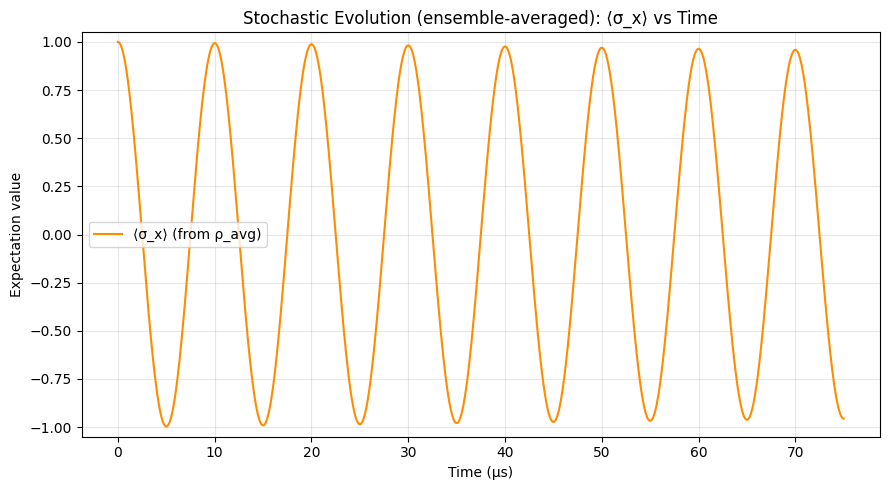

Final state fidelity vs ideal rotation (ensemble-averaged): 0.499630
Infidelity: 5.003700e-01


In [14]:
# State Evolution and Fidelity with Stochastic Noise (Amplitude Noise on Drive)
# Gate parameters for a sqrt(X) gate
# Rotate about y-axis so ⟨σ_z⟩ evolves from the x-start state

phi = np.pi/2  # Rotation around y-axis
theta = np.pi/2  # 90-degree rotation
tau = 30 * abs(theta)/rabi_rate  # Gate duration

# Initial state: superposition (|0⟩ + |1⟩)/√2 to probe ⟨σ_x⟩
coefs = np.zeros(len(basis.states), dtype=complex)
coefs[0] = 1/np.sqrt(2)
coefs[1] = 1/np.sqrt(2)

initial_state = sm.State.from_coefficients(basis, list(coefs))

# Build the Stochastic Hamiltonian (amplitude noise on resonant drive)
hamiltonian = R_hamiltonian(
    basis, phi, rabi_rate, omega,
    sparse=sparse, mod=None,
    stochastic=True)

# Time points for evolution
num_points = 2000  # moderate resolution
times = np.linspace(0, tau, num_points)

# Stochastic noise parameters (conservative for stability)
n_trajectories_requested = 20000
noise_strength = 0.2  # reduced strength
variance = (noise_strength * rabi_rate) ** 2

try:
    import numba  # type: ignore
    trajectory_backend = "numba"
    n_trajectories = n_trajectories_requested
    print("Numba available: using 'numba' backend for stochastic trajectories.")
except ImportError:
    trajectory_backend = "python"
    max_python_trajectories = 2000
    n_trajectories = min(n_trajectories_requested, max_python_trajectories)
    if n_trajectories < n_trajectories_requested:
        print(
            f"Numba not available: reducing trajectories from {n_trajectories_requested} to {n_trajectories} for 'python' backend."
        )
    else:
        print("Numba not available: using 'python' backend for stochastic trajectories.")

# Generate noisy trajectories for amplitude noise
noisy_traj = np.ascontiguousarray(
    sm.noise.StochasticNoise.white_noise(
        n_trajectories=n_trajectories,
        rng=np.random.default_rng(123),
        target_variance=variance,
        time_evals=times
    ),
    dtype=np.float64,
)

print(f"\nPropagating state with stochastic noise from t=0 to t={tau*1e6:.2f} μs, with {n_trajectories} trajectories using the '{trajectory_backend}' backend  ...")
start = time.perf_counter()
states_avg = initial_state.propagate_using_stochastic_schrodinger_equation(
    hamiltonian,
    time_evals=times,
    noisy_trajectories=noisy_traj,
    base_solver='solve_ivp',
    trajectory_backend=trajectory_backend,
    return_density_average=True,
)
end = time.perf_counter()
print(f"Stochastic propagation took {end - start:.3f} s.")

# Operators (lifted to basis)
x_op = basis.enlarge_matrix(sm.Pauli.X, [target_spins[0]])
z_op = basis.enlarge_matrix(sm.Pauli.Z, [target_spins[0]])

# Compute ⟨σ_x⟩, ⟨σ_z⟩ via Tr[ρ_avg O]
sx_expect = np.array([float(np.real(np.trace(st.density_matrix @ x_op))) for st in states_avg])
sz_expect = np.array([float(np.real(np.trace(st.density_matrix @ z_op))) for st in states_avg])

# Plot ⟨σ_x⟩ and ⟨σ_z⟩ expectation values over time
plt.figure(figsize=(9, 5))
plt.plot(times*1e6, sx_expect, label='⟨σ_x⟩ (from ρ_avg)', color='darkorange')
# plt.plot(times*1e6, sz_expect, label='⟨σ_z⟩ (from ρ_avg)', color='steelblue', alpha=0.85)
plt.xlabel('Time (μs)')
plt.ylabel('Expectation value')
# plt.title('Stochastic Evolution (ensemble-averaged): ⟨σ_x⟩ and ⟨σ_z⟩ vs Time')
plt.title('Stochastic Evolution (ensemble-averaged): ⟨σ_x⟩ vs Time')

plt.ylim(-1.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute ideal final pure state and its density matrix ρ_ideal
U = sm.Unitary.R(phi, theta)
psi_ideal = U @ initial_state.wavefunction
rho_ideal = np.outer(psi_ideal, np.conjugate(psi_ideal))

# Compute fidelity via Tr[ρ_avg ρ_ideal]
rho_avg_final = states_avg[-1].density_matrix
fidelity = float(np.real(np.trace(rho_avg_final @ rho_ideal)))
print(f"Final state fidelity vs ideal rotation (ensemble-averaged): {fidelity:.6f}")
print(f"Infidelity: {1-fidelity:.6e}")

### Fidelity vs Noise Strength (ensemble-averaged)

Numba available: using 'numba' backend for fidelity sweep trajectories.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.
Solving ODE with stochastic.


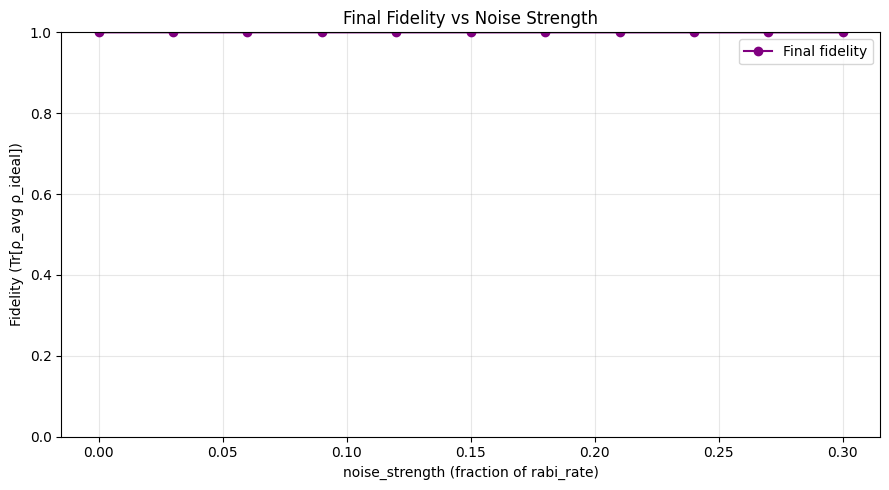

Min fidelity: 0.999864 at noise_strength=0.300
Max fidelity: 1.000000 at noise_strength=0.000


In [8]:
# Sweep noise_strength and compute final fidelity via Tr[ρ_avg ρ_ideal]
noise_strengths = np.linspace(0.0, 0.3, 11)
fidelities = []

# Use consistent gate duration tied to theta (avoid mismatched τ)
phi_sweep = phi
theta_sweep = theta
tau_sweep = abs(theta_sweep) / rabi_rate
num_points_sweep = 800
times_sweep = np.linspace(0, tau_sweep, num_points_sweep)

# Rebuild Hamiltonian to avoid any stale state tied to prior τ
hamiltonian_sweep = R_hamiltonian(
    basis,
    phi_sweep,
    rabi_rate,
    omega,
    sparse=sparse,
    mod=None,
    stochastic=True,
)

# Initial state as in the stochastic example
initial_state_sweep = initial_state  # same |+> superposition

# Ideal reference built from the same rotation parameters
U_sweep = sm.Unitary.R(phi_sweep, theta_sweep)
psi_ideal_sweep = U_sweep @ initial_state_sweep.wavefunction
rho_ideal_sweep = np.outer(psi_ideal_sweep, np.conjugate(psi_ideal_sweep))

# Select backend once for the sweep to reuse the Numba kernel if available
try:
    import numba  # type: ignore
    sweep_backend = "numba"
    sweep_trajectories = n_trajectories
    print("Numba available: using 'numba' backend for fidelity sweep trajectories.")
except ImportError:
    sweep_backend = "python"
    max_python_trajectories = 4000
    sweep_trajectories = min(n_trajectories, max_python_trajectories)
    if sweep_trajectories < n_trajectories:
        print(
            f"Numba not available: reducing trajectories from {n_trajectories} to {sweep_trajectories} for 'python' backend sweep.",
        )
    else:
        print("Numba not available: using 'python' backend for fidelity sweep trajectories.")

rng = np.random.default_rng(321)
for ns in noise_strengths:
    variance = (ns * rabi_rate) ** 2
    noisy_traj = np.ascontiguousarray(
        sm.noise.StochasticNoise.white_noise(
            n_trajectories=sweep_trajectories,
            rng=rng,
            target_variance=variance,
            time_evals=times_sweep,
        ),
        dtype=np.float64,
    )
    states_avg = initial_state_sweep.propagate_using_stochastic_schrodinger_equation(
        hamiltonian_sweep,
        time_evals=times_sweep,
        noisy_trajectories=noisy_traj,
        base_solver="solve_ivp",
        trajectory_backend=sweep_backend,
        return_density_average=True,
    )
    rho_avg_final = states_avg[-1].density_matrix
    fid = float(np.real(np.trace(rho_avg_final @ rho_ideal_sweep)))
    fidelities.append(fid)

plt.figure(figsize=(9, 5))
plt.plot(noise_strengths, fidelities, "o-", color="purple", label="Final fidelity")
plt.xlabel("noise_strength (fraction of rabi_rate)")
plt.ylabel("Fidelity (Tr[ρ_avg ρ_ideal])")
plt.title("Final Fidelity vs Noise Strength")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Min fidelity: {min(fidelities):.6f} at noise_strength={noise_strengths[int(np.argmin(fidelities))]:.3f}")
print(f"Max fidelity: {max(fidelities):.6f} at noise_strength={noise_strengths[int(np.argmax(fidelities))]:.3f}")

### Purity over Time (ensemble-averaged)

Solving ODE with stochastic.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with solve_ivp.
Solving ODE with so

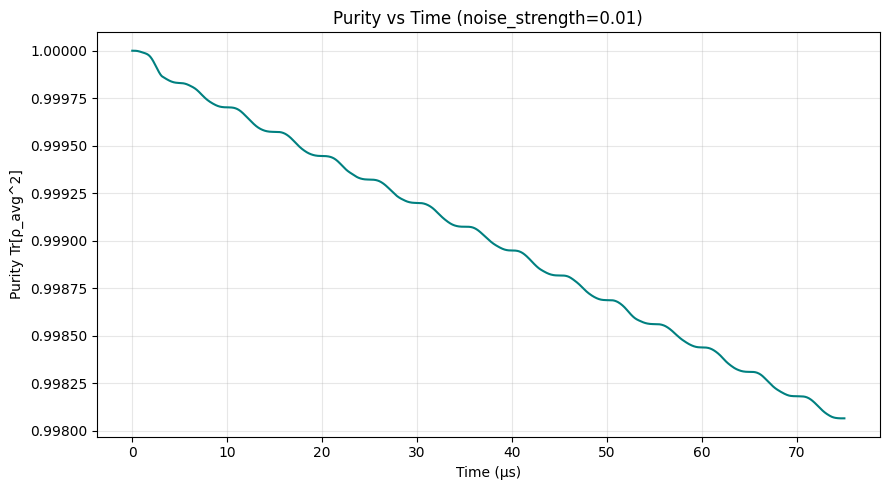

In [9]:
# Plot Tr[ρ_avg(t)^2] for a chosen noise strength
noise_strength_purity = 0.01
variance = (noise_strength_purity * rabi_rate) ** 2
noisy_traj = sm.noise.StochasticNoise.white_noise(
    n_trajectories=n_trajectories,
    rng=np.random.default_rng(999),
    target_variance=variance,
    time_evals=times
)
states_avg_purity = initial_state.propagate_using_stochastic_schrodinger_equation(
    hamiltonian,
    time_evals=times,
    noisy_trajectories=noisy_traj,
    base_solver='solve_ivp',
    return_density_average=True,
)

def _ensure_trace_one(r):
    tr = float(np.real(np.trace(r)))
    return r if abs(tr-1.0) < 1e-10 else (r / tr)

purity = np.array([
    float(np.real(np.trace(r@r)))
    for r in (_ensure_trace_one(st.density_matrix) for st in states_avg_purity)
])

print(f'Initial purity: {purity[0]:.6f}; Final purity: {purity[-1]:.6f}')

from matplotlib.ticker import ScalarFormatter
plt.figure(figsize=(9,5))
plt.plot(times*1e6, purity, color='teal')
plt.xlabel('Time (μs)')
plt.ylabel('Purity Tr[ρ_avg^2]')
plt.title(f'Purity vs Time (noise_strength={noise_strength_purity})')
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 2: Process Fidelity with Noise

Now we compute the process fidelity (gate fidelity) including frequency noise.

Process fidelity measures how well the entire gate operation (not just a single output state) matches the ideal gate.

In [10]:
phi = 0
theta = np.pi/2

# Error parameters
domega = 0  # Mean frequency error
half_box_width = 50 * 2*np.pi*1e3  # ±50 kHz noise width

noise = half_box_width

print(f"Computing process fidelity with:")
print(f"  Frequency error: {domega / (2*np.pi*1e3):.1f} kHz")
print(f"  Noise width: ±{noise / (2*np.pi*1e3):.1f} kHz")

start = time.perf_counter()
fid = process_fidelity(phi, theta, domega, noise)
end = time.perf_counter()

print(f"\nProcess fidelity: {fid:.6f}")
print(f"Infidelity: {1-fid:.6e}")

Computing process fidelity with:
  Frequency error: 0.0 kHz
  Noise width: ±50.0 kHz
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solvi

## Example 3: Gate Fidelity vs. Frequency Error

Now we'll explore how frequency detuning affects gate performance by sweeping through a range of frequency errors and computing the fidelity at each point.

This demonstrates:
- Sensitivity to laser frequency miscalibration
- How robust the gate is to frequency control errors
- The practical tolerance requirements for experimental implementation

In [11]:
phi = 0
theta = np.pi/2
half_box_width = 0  # No stochastic noise for simplicity

# Sweep frequency error from -100 kHz to +100 kHz
frequency_errors = np.linspace(-100 * 2*np.pi*1e3, 100 * 2*np.pi*1e3, 21)

print(f"Sweeping frequency error from {frequency_errors[0]/(2*np.pi*1e3):.1f} to {frequency_errors[-1]/(2*np.pi*1e3):.1f} kHz")
print(f"Computing {len(frequency_errors)} gate simulations...")

# Compute fidelity at each frequency error
fidelities = []
start_sweep = time.perf_counter()

for i, domega in enumerate(frequency_errors):
    gate = R(phi, theta, domega, half_box_width)
    fid = gate.compute_process_fidelity(ideal_R(phi, theta).process_matrix)
    fidelities.append(fid)
    
    if (i + 1) % 5 == 0:
        print(f"  Completed {i+1}/{len(frequency_errors)} simulations...")

end_sweep = time.perf_counter()
print(f"\nTotal sweep time: {end_sweep - start_sweep:.2f} s")
print(f"Average time per gate: {(end_sweep - start_sweep)/len(frequency_errors):.3f} s")

# Find the frequency with worst fidelity
worst_idx = np.argmin(fidelities)
print(f"\nBest fidelity: {max(fidelities):.6f} at {frequency_errors[np.argmax(fidelities)]/(2*np.pi*1e3):.1f} kHz")
print(f"Worst fidelity: {min(fidelities):.6f} at {frequency_errors[worst_idx]/(2*np.pi*1e3):.1f} kHz")

Sweeping frequency error from -100.0 to 100.0 kHz
Computing 21 gate simulations...
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
  Completed 5/21 simulations...
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
  Completed 10/21 simulations...
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
Solving ODE with odeintz.
  Completed 15/21 simulations...
Solving ODE with odeintz.
Solving ODE w

### Visualize Fidelity vs. Frequency Error

Plot how gate fidelity degrades as the laser frequency deviates from the ideal resonance condition.

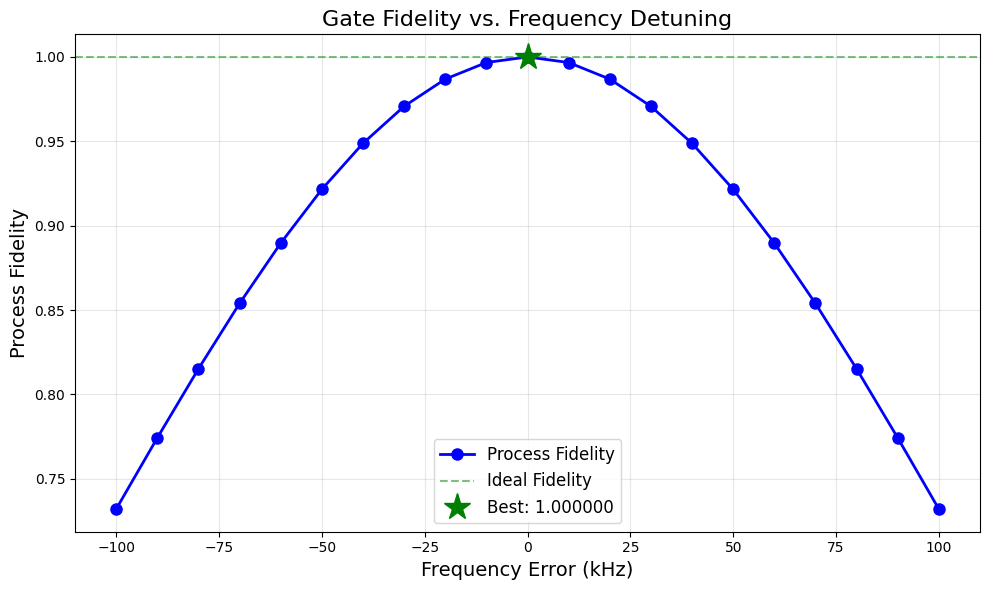

In [12]:
plt.figure(figsize=(10, 6))

# Plot fidelity
plt.plot(frequency_errors / (2*np.pi*1e3), fidelities, 'o-', 
         linewidth=2, markersize=8, color='blue', label='Process Fidelity')

# Add horizontal line at ideal fidelity
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Ideal Fidelity')

# Highlight the best point
best_idx = np.argmax(fidelities)
plt.plot(frequency_errors[best_idx] / (2*np.pi*1e3), fidelities[best_idx], 
         'g*', markersize=20, label=f'Best: {fidelities[best_idx]:.6f}')

plt.xlabel('Frequency Error (kHz)', fontsize=14)
plt.ylabel('Process Fidelity', fontsize=14)
plt.title('Gate Fidelity vs. Frequency Detuning', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we:

1. **Set up** a trapped-ion qubit system using 171Yb+ ions
2. **Constructed** the Hamiltonian for an R gate with resonant laser drive
3. **Simulated** state evolution under the gate and verified high fidelity
4. **Computed** process fidelity including frequency noise effects
5. **Analyzed** gate sensitivity to frequency detuning through parameter sweeps

Key takeaways:
- The R gate achieves high fidelity when the laser is on-resonance
- Frequency errors degrade gate performance - the relationship between detuning and fidelity shows how tight frequency control must be
- Process fidelity provides a complete characterization of gate quality beyond single-state measurements

### Next Steps

You could extend this analysis by:
- Sweeping other error parameters (Rabi rate errors, pulse timing, etc.)   
- Adding multiple noise sources simultaneously
- Exploring different gate types (MS gates, multi-qubit operations)
- Implementing composite pulse sequences for error suppression
- Analyzing gate performance with motional modes included

## Tutorial Flow Graph

```
                    ┌─────────────────────────┐
                    │  sm.AtomicSpin          │
                    │  .from_species()        │
                    │  Define 171Yb+ qubit    │
                    └───────────┬─────────────┘
                                │
                                ↓
                    ┌─────────────────────────┐
                    │  sm.StandardBasis()     │
                    │  Build |0⟩,|1⟩ basis     │
                    └───────────┬─────────────┘
                                │
                                ↓
                    ┌─────────────────────────┐
                    │  basis.enlarge_matrix() │
                    │  (sm.Pauli.plus)        │
                    │  Lift σ₊ operator to    │
                    │ desired size of Hilbert │
                    └───────────┬─────────────┘
                                │
                                ↓
                    ┌─────────────────────────┐
                    │  sm.CouplingOperator    │
                    │  .from_matrix()         │
                    │  Create coupling with   │
                    │ oscillating frequency   │
                    │ omega                   │
                    └───────────┬─────────────┘
                                │
                                ↓
                    ┌─────────────────────────┐
                    │  sm.Hamiltonian()       │
                    │  Assemble full H(t)     │
                    └───────────┬─────────────┘
                                │
                ┌───────────────┴───────────────┐
                │                               │
                ↓                               ↓
    ┌───────────────────────┐       ┌───────────────────────┐
    │  STATE-LEVEL PATH     │       │  GATE-LEVEL PATH      │
    │  (Example 1)          │       │  (Examples 2 & 3)     │
    │  Track wavefunction   │       │  Evaluate full gate   │
    └───────────┬───────────┘       └───────────┬───────────┘
                │                               │
                ↓                        ┌──────┴──────────┐
    ┌───────────────────────┐    ┌──────────────────────┐  │
    │  sm.State             │    │  sm.Gate             │  │
    │  .from_coefficients() │    │  .from_hamiltonian() │  │
    │  Initialize |0⟩ state │    │ Build Hamiltonian    │  │
    └───────────┬───────────┘    └───┬──────────────────┘  │
                │                │ simulated_R()    │      │
                ↓                │ Build Gate from H│      │
    ┌───────────────────────┐        │                     │
    │  state.propagate_     │        ↓                     ↓
    │  using_schrodinger_   │  ┌─────────────┐   ┌─────────────────┐
    │  equation()           │  │  NOISY R()  │   │  IDEAL ideal_R()│
    │  Evolve over time     │  │  GATE       │   │  GATE           │
    └───────────┬───────────┘  │  With errors│   │  Perfect unitary│
                │              └──────┬──────┘   └────────┬────────┘
                ↓                     │                   │
    ┌───────────────────────┐         ↓                   ↓
    │  state.compute_basis_ │  ┌──────────────────┐ ┌─────────────────┐
    │  state_probabilities()│  │ sm.Noise         │ │ sm.Gate         │
    │  Measure each level   │  │ .from_named_pdf()│ │ .from_unitary() │
    └───────────┬───────────┘  │ Define noise     │ │      Ideal      │
                │              └─────────┬────────┘ │ Analytic gate   │
                ↓                        │          └──────┬──────────┘
    ┌───────────────────────┐            ↓                 │
    │  state.compute_state_ │  ┌─────────────────────┐     │
    │  fidelity()           │  │ sm.Gate.from_       │     │
    │  Compare to target    │  │ process_matrix_     │     │
    └───────────────────────┘  │ function()          │     │
                               │ Construct noisy gate│     │
                               │ from noise-evaluated│     │ 
                               │ process matrix      │     │
                               └─────────┬───────────┘     │
                                         │                 │
                                         └────────┬────────┘
                                                  │
                                                  ↓
                                      ┌────────────────────────┐
                                      │ gate.compute_process_  │
                                      │ fidelity()             │
                                      │ Quantify gate quality  │
                                      └────────────────────────┘
                                                  │
                                      ┌───────────┴───────────┐
                                      │                       │
                                      ↓                       ↓
                          ┌────────────────────┐  ┌────────────────────┐
                          │  Example 2:        │  │  Example 3:        │
                          │  Single fidelity   │  │  Parameter sweep   │
                          │  with noise        │  │  (loop over many   │
                          │  One data point    │  │  frequency errors) │
                          └────────────────────┘  │  Multiple data points│
                                                  └────────────────────┘
```